Précision du modèle : 100.00%


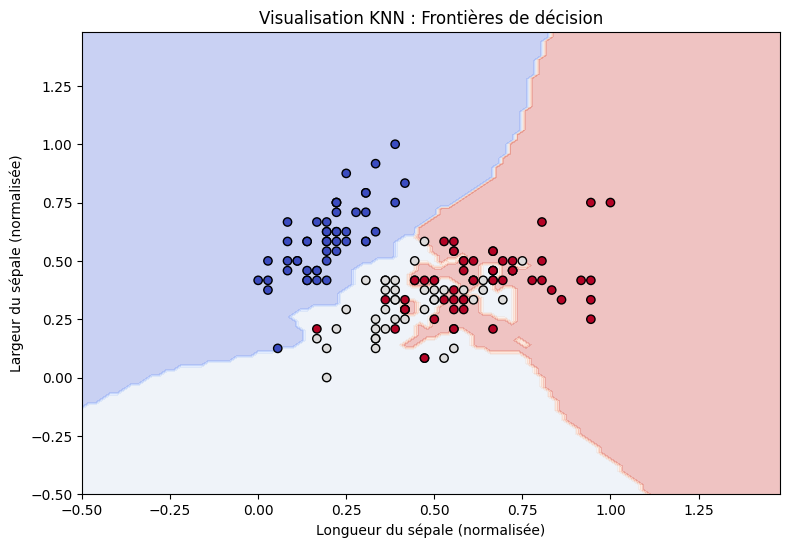

In [7]:
# --- 1. Importation des bibliothèques nécessaires ---
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# --- 2. Chargement et préparation des données ---
# Charger le jeu de données Iris
iris = load_iris()
X = iris.data
y = iris.target

# Normalisation des données (essentiel pour la distance euclidienne de KNN)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Division des données en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- 3. Entraînement du modèle KNN ---
# Création du classifieur avec 3 voisins
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn.fit(X_train, y_train)

# Prédictions et évaluation
predictions = knn.predict(X_test)
score = knn.score(X_test, y_test)
print(f"Précision du modèle : {score * 100:.2f}%")

# --- 4. Visualisation des frontières de décision ---
# On utilise seulement les deux premières caractéristiques pour la visualisation 2D
X_viz = X_scaled[:, :2] 
knn_viz = KNeighborsClassifier(n_neighbors=3)
knn_viz.fit(X_viz, y)

# Création d'une grille pour dessiner les zones
x_min, x_max = X_viz[:, 0].min() - 0.5, X_viz[:, 0].max() + 0.5
y_min, y_max = X_viz[:, 1].min() - 0.5, X_viz[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Prédire les classes pour chaque point de la grille
Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Tracé du graphique
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm) # Zones de décision
plt.scatter(X_viz[:, 0], X_viz[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm) # Points de données
plt.xlabel('Longueur du sépale (normalisée)')
plt.ylabel('Largeur du sépale (normalisée)')
plt.title('Visualisation KNN : Frontières de décision')
plt.show()